In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from ant.market import Market
from ant.decentralised.dynamic import COAPAgent
from ant.decentralised.direct import ProportionalAgent
from ant.centralised import P4
from ant.decentralised.utility import create_grid_graph

In [10]:
NUM_SEEDS = 10
MARKET_SIZE = 80
SIMULATION_DURATION = 50
WINDOW_START = 0
WINDOW_END = min(SIMULATION_DURATION, 50)

KS = [1, 2, 3]
BENCHMARKS = ["Proportional"]
TARGET_AGENTS = ["COAP"]

GRAPH_TYPES = ["Fully Connected", "Random", "Grid", "Small-World"]

# number of threads / workers (idk how parallel python works)
NUM_WORKERS = 8

In [11]:
def create_graphs(n, seed):
    graphs = {
        "Fully Connected": nx.complete_graph(n),
        "Random": nx.erdos_renyi_graph(n, 0.05),
        # "Random": nx.gnp_random_graph(n, 0.1, seed=seed),
        "Grid": create_grid_graph(n),
        "Small-World": nx.watts_strogatz_graph(n, int(n / 2), 0.05, seed=seed),
    }
    if not nx.is_connected(graphs["Random"]):
        return create_graphs(n, seed + NUM_SEEDS)
    return graphs

In [12]:
def run_single_seed(seed_idx):
    """
    Runs the entire simulation logic for a single seed index.
    Returns a dictionary of results for this specific seed.
    """
    current_seed = seed_idx

    graphs = create_graphs(MARKET_SIZE, seed=current_seed)

    seed_results = {}
    seed_crashes = {}

    for graph_type, graph_obj in graphs.items():
        seed_results[graph_type] = {
            "COAP": {k: None for k in KS},
            **{b: {None: None} for b in BENCHMARKS},
        }
        seed_crashes[graph_type] = {
            "COAP": {k: None for k in KS},
            **{b: {None: None} for b in BENCHMARKS},
        }

        for k in KS:
            _market = Market(
                MARKET_SIZE,
                graph=graph_obj,
                seed=current_seed,
                agent_type=COAPAgent,
                resource_volatility=0.01,
                k=k,
                report_crashes=True,
            )

            optimal_allocations, utility_vector = P4(_market)
            _market.set_market_equilibrium(optimal_allocations, utility_vector)

            sim_result = _market.simulate(
                SIMULATION_DURATION,
                use_average_in_market_loss=True,
                return_proportional_utility_instead_of_market_loss=False,
            )

            window_data = sim_result[WINDOW_START:WINDOW_END]

            crash_count = sum(
                [1 if agent.has_crashed else 0 for agent in _market.agents]
            )
            health_rate = 1.0 - (crash_count / len(_market.agents))

            seed_results[graph_type]["COAP"][k] = window_data
            seed_crashes[graph_type]["COAP"][k] = health_rate

        for b_agent in BENCHMARKS:
            agent_type = ProportionalAgent if b_agent == "Proportional" else None

            if agent_type:
                _market = Market(
                    MARKET_SIZE,
                    graph=graph_obj,
                    seed=current_seed,
                    agent_type=agent_type,
                )

                optimal_allocations, utility_vector = P4(_market)
                _market.set_market_equilibrium(optimal_allocations, utility_vector)

                sim_result = _market.simulate(
                    SIMULATION_DURATION,
                    use_average_in_market_loss=True,
                    return_proportional_utility_instead_of_market_loss=False,
                )

                window_data = sim_result[WINDOW_START:WINDOW_END]

                seed_results[graph_type][b_agent][None] = window_data
                seed_crashes[graph_type][b_agent][None] = 1.0

    return {"seed_idx": seed_idx, "data": seed_results, "crashes": seed_crashes}

In [13]:
results_store = {}
crash_rates_store = {}

for gt in GRAPH_TYPES:
    results_store[gt] = {
        "COAP": {k: [] for k in KS},
        **{b: {None: []} for b in BENCHMARKS},
    }
    crash_rates_store[gt] = {
        "COAP": {k: [] for k in KS},
        **{b: {None: []} for b in BENCHMARKS},
    }

In [14]:
print(
    f"Starting parallel execution with {NUM_WORKERS} threads for {NUM_SEEDS} seeds..."
)

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    future_to_seed = {
        executor.submit(run_single_seed, seed_idx): seed_idx
        for seed_idx in range(NUM_SEEDS)
    }

    completed_count = 0
    for future in as_completed(future_to_seed):
        seed_idx = future_to_seed[future]
        try:
            result = future.result()

            data_dict = result["data"]
            crash_dict = result["crashes"]

            for gt in GRAPH_TYPES:
                # COAP
                for k in KS:
                    results_store[gt]["COAP"][k].append(data_dict[gt]["COAP"][k])
                    crash_rates_store[gt]["COAP"][k].append(crash_dict[gt]["COAP"][k])

                # Benchmarks
                for b in BENCHMARKS:
                    results_store[gt][b][None].append(data_dict[gt][b][None])
                    crash_rates_store[gt][b][None].append(crash_dict[gt][b][None])

            completed_count += 1
            print(f"Completed seed {completed_count}/{NUM_SEEDS}")

        except Exception as exc:
            print(f"Seed {seed_idx} generated an exception: {exc}")

print("All simulations finished. Aggregating results...")

Starting parallel execution with 8 threads for 10 seeds...
Completed seed 1/10
Completed seed 2/10
Completed seed 3/10
Completed seed 4/10
Completed seed 5/10
Completed seed 6/10
Completed seed 7/10
Completed seed 8/10
Completed seed 9/10
Completed seed 10/10
All simulations finished. Aggregating results...


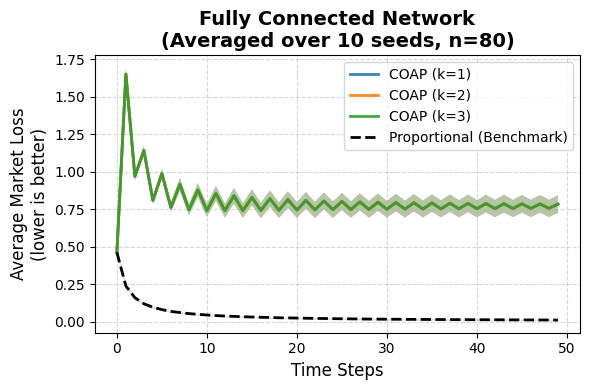


--- Summary Stats for Fully Connected ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.7843          0.0592          100.00%
COAP            2     0.7843          0.0592          100.00%
COAP            3     0.7843          0.0592          100.00%
Proportional    -     0.0108          0.0005          100.00%


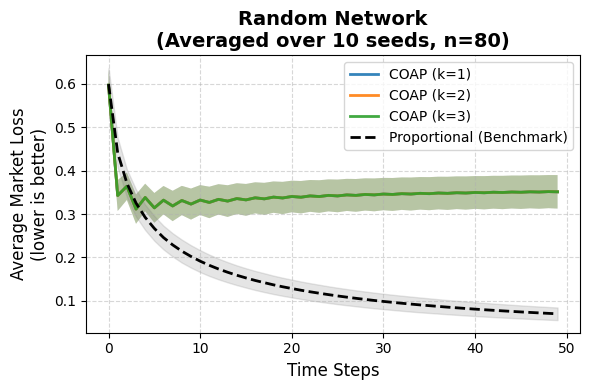


--- Summary Stats for Random ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.3511          0.0386          100.00%
COAP            2     0.3511          0.0386          100.00%
COAP            3     0.3511          0.0386          100.00%
Proportional    -     0.0701          0.0145          100.00%


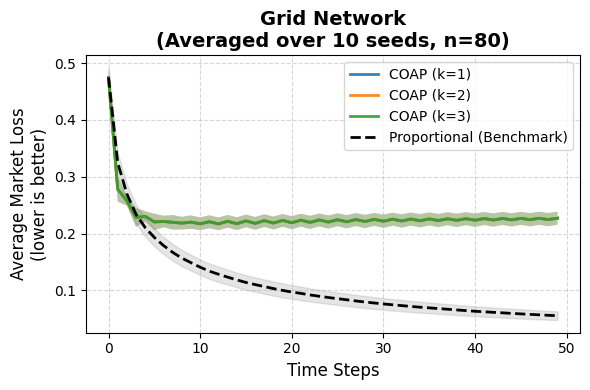


--- Summary Stats for Grid ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.2272          0.0115          100.00%
COAP            2     0.2272          0.0115          100.00%
COAP            3     0.2272          0.0115          100.00%
Proportional    -     0.0556          0.0077          100.00%


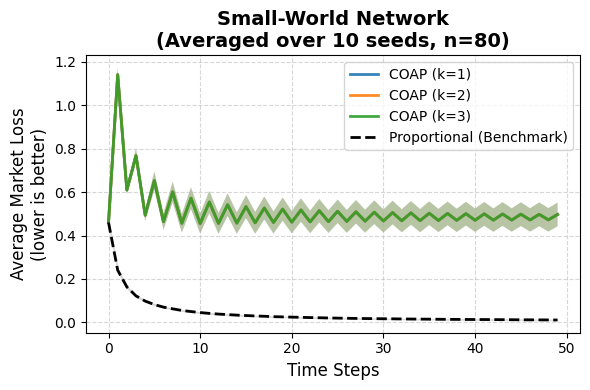


--- Summary Stats for Small-World ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.4971          0.0547          100.00%
COAP            2     0.4971          0.0547          100.00%
COAP            3     0.4971          0.0547          100.00%
Proportional    -     0.0110          0.0006          100.00%


In [17]:
time_steps = np.arange(WINDOW_START, WINDOW_END)

for graph_type in results_store.keys():
    plt.figure(figsize=(6, 4))
    axis = plt.gca()

    # Plot COAP agents
    for k in KS:
        data_list = results_store[graph_type]["COAP"][k]

        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)

            label = f"COAP (k={k})"

            plt.plot(time_steps, mean_loss, label=label, alpha=0.9, linewidth=2)
            plt.fill_between(
                time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2
            )

    # Plot Benchmarks
    for bench in BENCHMARKS:
        data_list = results_store[graph_type][bench][None]
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)

            label = f"{bench} (Benchmark)"

            plt.plot(
                time_steps,
                mean_loss,
                label=label,
                linestyle="--",
                color="black",
                linewidth=2,
            )
            plt.fill_between(
                time_steps,
                mean_loss - std_loss,
                mean_loss + std_loss,
                alpha=0.2,
                color="gray",
            )

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Average Market Loss\n(lower is better)", fontsize=12)
    plt.title(
        f"{graph_type} Network\n(Averaged over {NUM_SEEDS} seeds, n={MARKET_SIZE})",
        fontsize=14,
        fontweight="bold",
    )
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print Summary Table for this graph type
    print(f"\n--- Summary Stats for {graph_type} ---")
    print(
        f"{'Strategy':<15} {'K':<5} {'Final Mean Loss':<15} {'Final Std Dev':<15} {'Avg Health'}"
    )
    print("-" * 60)

    # COAP Agents
    for k in KS:
        data = results_store[graph_type]["COAP"][k]
        if data:
            # Take the last element of every seed run
            final_values = [d[-1] if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            final_std = float(np.std(final_values))
            avg_health = float(np.mean(crash_rates_store[graph_type]["COAP"][k]))
            print(
                f"{'COAP':<15} {str(k):<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}"
            )

    # Benchmark Agents
    for bench in BENCHMARKS:
        data = results_store[graph_type][bench][None]
        if data:
            # Data check
            final_values = [float(d[-1]) if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))

            final_std = float(np.std(final_values))

            # Calculate health. 100% unless COAP crashed
            rates = crash_rates_store[graph_type][bench][None]
            avg_health = float(np.mean(rates)) if rates else 1.0

            print(
                f"{bench:<15} {'-':<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}"
            )
        else:
            print(f"{bench:<15} {'-':<5} {'N/A':<15} {'N/A':<15} {'N/A':<10}")